# Alpha Vantage Sentiment vs. FinBERT — Benchmark

**News Sentiment as a Trading Signal** · AAI-590 Capstone · Syed Sirajuddin

News acquisition now lives in Notebook 01, which fetches from Alpha Vantage, cleans, and writes `news_clean.parquet`; Notebook 03 scores those articles with FinBERT and writes `news_scored.parquet`. Because every article already carries **both** scores — the project's FinBERT `score` and Alpha Vantage's own `av_sentiment_score` — this notebook does one focused thing: it benchmarks the two independent sentiment measures against each other.

This is the payoff of using Alpha Vantage as the source rather than a bare news feed. A purpose-built academic model (FinBERT) and an independent commercial model scored the *same* headlines, so their agreement is directly measurable. High agreement corroborates both; systematic disagreement is itself a finding worth discussing in the report.

In [1]:
%matplotlib inline
# --- Setup ---
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.config import PROCESSED_DIR

scored = pd.read_parquet(PROCESSED_DIR / "news_scored.parquet")
print(f"{len(scored):,} scored articles")
print("Has FinBERT score:", "score" in scored.columns)
print("Has Alpha Vantage score:", "av_sentiment_score" in scored.columns)
from pathlib import Path
FIGDIR = ROOT / "reports" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

95,758 scored articles
Has FinBERT score: True
Has Alpha Vantage score: True


## 1. Score agreement

Both scores live on the same [-1, +1] scale. The comparison uses three measures:

- **Pearson correlation** — linear agreement of the raw scores.
- **Spearman correlation** — agreement of the rank ordering, robust to scale differences between the two models.
- **Directional agreement** — the fraction of articles the two models place on the same side of neutral, which is what actually matters for a long/short signal.

In [2]:
both = scored.dropna(subset=["score", "av_sentiment_score"]).copy()
print(f"Articles scored by both models: {len(both):,}")

pearson  = both["score"].corr(both["av_sentiment_score"])
spearman = both["score"].corr(both["av_sentiment_score"], method="spearman")
same_dir = ((both["score"] > 0) == (both["av_sentiment_score"] > 0)).mean()

print(f"Pearson correlation:   {pearson:.3f}")
print(f"Spearman correlation:  {spearman:.3f}")
print(f"Directional agreement: {same_dir:.1%}")

Articles scored by both models: 95,758
Pearson correlation:   0.369
Spearman correlation:  0.346
Directional agreement: 75.0%


## 2. Where they agree and disagree

The scatter shows the joint distribution of the two scores; the diagonal is perfect agreement. The confusion-style table crosses each model's three-way label (negative / neutral / positive, split at ±0.15) so that systematic biases are visible — for example, whether one model is more willing to call an article strongly polar than the other.

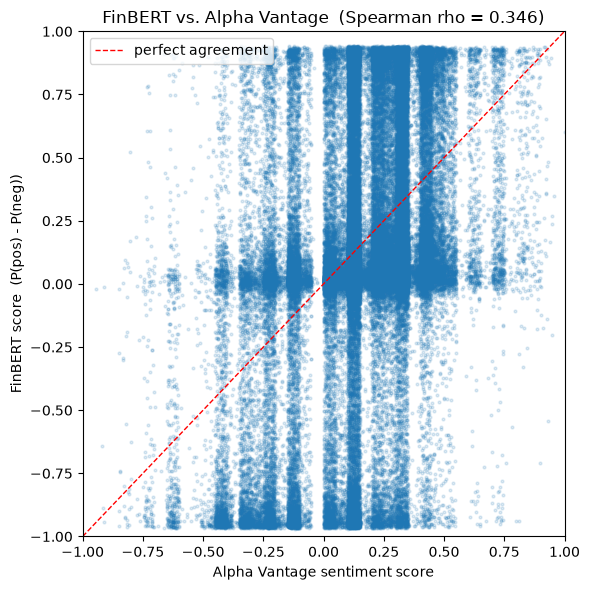

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(both["av_sentiment_score"], both["score"], s=4, alpha=0.15)
lim = [-1, 1]
ax.plot(lim, lim, "r--", lw=1, label="perfect agreement")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Alpha Vantage sentiment score")
ax.set_ylabel("FinBERT score  (P(pos) - P(neg))")
ax.set_title(f"FinBERT vs. Alpha Vantage  (Spearman rho = {spearman:.3f})")
ax.legend()
plt.tight_layout(); plt.savefig(FIGDIR / "benchmark_finbert_vs_av.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
def to_label(s):
    return np.where(s >= 0.15, "positive",
           np.where(s <= -0.15, "negative", "neutral"))

both["finbert_label"] = to_label(both["score"])
both["av_label"] = to_label(both["av_sentiment_score"])

confusion = pd.crosstab(both["finbert_label"], both["av_label"],
                        rownames=["FinBERT"], colnames=["Alpha Vantage"],
                        normalize="all").round(3)
print("Joint label distribution (share of all dual-scored articles):")
print(confusion.to_string())
agree_3way = (both["finbert_label"] == both["av_label"]).mean()
print(f"\nThree-way label agreement: {agree_3way:.1%}")

Joint label distribution (share of all dual-scored articles):
Alpha Vantage  negative  neutral  positive
FinBERT                                   
negative          0.052    0.080     0.036
neutral           0.030    0.205     0.237
positive          0.015    0.114     0.231

Three-way label agreement: 48.8%


## 3. Interpretation

Across all 95,758 dual-scored articles, FinBERT and Alpha Vantage's independent commercial model show a **Pearson correlation of 0.369**, a **Spearman correlation of 0.346**, **directional agreement of 75.0%** (same sign of sentiment), and **three-way label agreement of 48.8%** (negative/neutral/positive split at ±0.15).

**What this means.** This is moderate, not strong, agreement, and that is the informative outcome. The two models were trained on different corpora with different objectives, so their substantial agreement (three of four articles share direction) indicates that a large part of what each calls "sentiment" is model-invariant, i.e. a real property of the news rather than an artifact of one model. The joint label table shows both models concentrate articles in the neutral-to-positive region, consistent with the generally upbeat tone of routine corporate coverage; most disagreement is between adjacent labels (neutral vs. mildly polar) rather than outright sign flips, which is why directional agreement (75%) far exceeds exact three-way agreement (49%).

**Why it matters for the project.** This benchmark establishes that the sentiment *measurement* is sound and reproducible across independent models. Consequently, when the trading strategy later fails to beat the null, that failure can be attributed to the *tradeability* of news sentiment, not to a defect in how sentiment was scored. Notebook 07 makes this explicit by re-running the entire strategy on the Alpha Vantage score and confirming the same negative result.

---
*Use of AI tools: I used Anthropic's Claude (Anthropic, 2026) to assist with this analysis code; I verified the outputs and take full responsibility for the content.*